___

# <font color= #f6c049> **Soda Pop Project: Perceptual Generative Autoencoder** </font>
#### <font color= #2E9AFE> `Deep Learning`</font>
<Strong> Sofía Maldonado, Óscar Josué Rocha & Viviana Toledo </Strong>

_03/03/2026._

___

In [1]:
# General
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Models
import tensorflow as tf
from tensorflow.python.client import device_lib
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Dropout, BatchNormalization, Add
from keras.optimizers import Adam
from keras import Model
from tensorflow.keras.applications.vgg19 import preprocess_input

# Loss Function
from tensorflow.keras.applications import VGG19
from tensorflow.keras import Model, Input

# Generative Model
from tensorflow import GradientTape

2026-03-02 01:44:17.937356: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  1


# <font color= #f6c049> **Modeling** </font>

This notebook covers the development of a Perceptual Generative Autoencoder (PGA) using VGG-19 as a perceptual loss function, and a convolutional autoencoder architecture.

## <font color= #dba226> &ensp; • **Perceptual Loss with VGG Model** </font>

The final convolutional layer from the VGG19 model is going to be extracted to use as a loss function. This layer contains deep patterns captured during training. The weights of the model will be freezed so that no more training is performed, and the layer is only used to compare the input images versus the generated ones.

In [3]:
def get_vgg_model():
    # Get VGG model trained with imagenet, with no fixed input shape
    vgg = VGG19(weights='imagenet', include_top=False, input_shape=(None, None, 3))
    vgg.trainable = False           # Freeze weights
    # Get the last conv layer
    loss_model = Model(inputs=vgg.input, outputs=vgg.get_layer('block5_conv4').output)
    loss_model.trainable = False
    return loss_model

vgg_model = get_vgg_model()

I0000 00:00:1772437459.652780   35588 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4143 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


With the previously extracted layer, a customized loss function is defined by calculating the difference between predicted and true images:

In [4]:
def perceptual_loss(y_true, y_pred):
    y_true_pp = preprocess_input(y_true * 255.0)
    y_pred_pp = preprocess_input(y_pred * 255.0)
    y_true_features = vgg_model(y_true_pp)
    y_pred_features = vgg_model(y_pred_pp)
    return tf.reduce_mean(tf.square(y_true_features - y_pred_features))

## <font color= #dba226> &ensp; • **Convolutional Autoencoder** </font>

Before starting the PGA, we import the previously normalized and resized images:

In [5]:
train_ds = tf.data.Dataset.load('../data/processed/train_ds')
val_ds = tf.data.Dataset.load('../data/processed/val_ds')
test_ds = tf.data.Dataset.load('../data/processed/test_ds')

The images have a size of 64x64 pixels. Thus, the dimensionality reduction within the autoencoder will be done as follows:

$$
4096_{input} \rightarrow 1024_{h_1} \rightarrow 256_{h_2} \rightarrow 64_z \leftarrow 256_{h_2} \leftarrow 1024_{h_1} \leftarrow 4096_{output}
$$

The first step is to build the encoder and decoder modules:

In [6]:
# Parameters
input_shape = (64,64,3)         # 4,096

# Input 
input_layer = Input(shape=input_shape)

# Encoder
enc_layer_1 = Conv2D(64, kernel_size=3, activation='relu', padding='same')(input_layer)         # 32x32             
enc_layer_1 = BatchNormalization()(enc_layer_1)
enc_layer_1 = Concatenate()([enc_layer_1, enc_layer_1])
enc_pool_1 = MaxPooling2D(pool_size=(2,2))(enc_layer_1)   # 32x32

enc_layer_2 = Conv2D(128, kernel_size=3, activation='relu', padding='same')(enc_pool_1)      # 16x16    
enc_layer_2 = BatchNormalization()(enc_layer_2)
enc_layer_2 = Concatenate()([enc_layer_2, enc_layer_2])
enc_pool_2 = MaxPooling2D(pool_size=(2,2))(enc_layer_2)   # 16x16

enc_layer_3 = Conv2D(128, kernel_size=3, activation='relu', padding='same')(enc_pool_2)      # 8x8   
enc_layer_3 = BatchNormalization()(enc_layer_3)
enc_layer_3 = Concatenate()([enc_layer_3, enc_layer_3])
enc_pool_3 = MaxPooling2D(pool_size=(2,2))(enc_layer_3)   # 8x8

latent_space = Conv2D(64, kernel_size=3, padding='same', activation='tanh')(enc_pool_3)

In [7]:
# Input
latent_input = Input(shape=latent_space.shape[1:])

# Decoder
dec_layer_1 = UpSampling2D()(latent_input)
dec_layer_1 = Conv2D(128, kernel_size=3, activation='relu', padding='same')(dec_layer_1)
dec_layer_1 = Concatenate()([dec_layer_1, dec_layer_1])

dec_layer_2 = UpSampling2D()(dec_layer_1)
dec_layer_2 = Conv2D(128, kernel_size=3, activation='relu', padding='same')(dec_layer_2)
dec_layer_2 = Concatenate()([dec_layer_2, dec_layer_2])

dec_layer_3 = UpSampling2D()(dec_layer_2)
dec_layer_3 = Conv2D(64, kernel_size=3, activation='relu', padding='same')(dec_layer_3)
dec_layer_3 = Concatenate()([dec_layer_3, dec_layer_3])

# Output
decoder_output = Conv2D(3, kernel_size=3, activation='sigmoid', padding='same')(dec_layer_3)

Where the autoencoder is the combination of both modules, and the generator (module which will generate images) is the decoder.

In [8]:
# Build Decoder
decoder = Model(latent_input, decoder_output, name='decoder')

# Build autoencoder
autoencoder = Model(input_layer, decoder(latent_space), name='autoencoder')     

# Extract encoder 
encoder = Model(input_layer, latent_space, name="encoder")

# Build Generator
generator = decoder

After building the model, we build a training function which **reconstructs the images using the perceptual loss function previously established**. Additionally, it shapes the latent space to follow a uniform distribution, and ensures that the samples are meaningful.

The alpha parameter penalizes the latent space and allows for learning within the model, which is why $\alpha = 10$, to better shape the latent space. 

Finally, gradients are computed to recalculate weights in the model based on the reconstruction loss.

In [ ]:
# Hyperparameters
optimizer = Adam(learning_rate=1e-4)
alpha = 10

# Train generative model
@tf.function
def train_step(X_real):
    with tf.GradientTape() as tape:
        # Encode real images
        z_real = encoder(X_real)
        # Add small noise for stability
        z_real_noisy = z_real + 0.05 * tf.random.normal(tf.shape(z_real))
        # Reconstruct images
        X_rec = generator(z_real_noisy)
        
        # Pixel + perceptual loss
        pixel_loss = tf.reduce_mean(tf.abs(X_real - X_rec))
        perc_loss = perceptual_loss(X_real, X_rec)
        rec_loss = 0.1 * pixel_loss + perc_loss

        # Sample latent space uniformly
        z_prior = tf.random.uniform(tf.shape(z_real), -1, 1)
        X_gen = generator(z_prior)
        z_gen = encoder(X_gen)

        # Latent distribution matching (L2 between latent codes)
        latent_loss = tf.reduce_mean(tf.square(z_real - z_gen))
        # Compute total loss
        total_loss = rec_loss + alpha * latent_loss

    # Apply gradients
    train_vars = autoencoder.trainable_variables
    gradients = tape.gradient(total_loss, train_vars)
    optimizer.apply_gradients(zip(gradients, train_vars))
    
    return total_loss

The model was computed across 100 epochs to hopefully make it **learn the image distributions and adjust both the encoder and decoder modules**. The idea is that the former produces a meaningful latent space and the latter reconstructs a realistic image based on the representation.

In [10]:
# Training loop
epochs = 100

for epoch in range(epochs):
    print(f'Epoch {epoch + 1} / {epochs}')
    for step, batch in enumerate(train_ds):
        loss = train_step(batch[0])
        if step % 100 == 0:
            print(f'Step: {step} \n Loss: {loss}')

Epoch 1 / 100


2026-03-02 01:44:22.985831: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


Step: 0 
 Loss: 48.35039520263672


2026-03-02 01:44:36.583046: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 2 / 100
Step: 0 
 Loss: 42.14968490600586


...

Epoch 17 / 100
Step: 0 
 Loss: 27.936058044433594
Epoch 18 / 100
Step: 0 
 Loss: 27.371145248413086
Epoch 19 / 100
Step: 0 
 Loss: 27.799407958984375
Epoch 20 / 100
Step: 0 
 Loss: 26.924570083618164
Epoch 21 / 100
Step: 0 
 Loss: 26.49317741394043
Epoch 22 / 100
Step: 0 
 Loss: 25.497947692871094
Epoch 23 / 100
Step: 0 
 Loss: 25.793338775634766
Epoch 24 / 100
Step: 0 
 Loss: 25.114614486694336
Epoch 25 / 100
Step: 0 
 Loss: 24.25213623046875
Epoch 26 / 100
Step: 0 
 Loss: 25.102628707885742
Epoch 27 / 100
Step: 0 
 Loss: 24.469074249267578
Epoch 28 / 100
Step: 0 
 Loss: 24.54767417907715
Epoch 29 / 100
Step: 0 
 Loss: 24.246349334716797
Epoch 30 / 100
Step: 0 
 Loss: 23.581928253173828
Epoch 31 / 100
Step: 0 
 Loss: 23.298357009887695
Epoch 32 / 100
Step: 0 
 Loss: 23.19862174987793


2026-03-02 01:47:55.385102: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 33 / 100
Step: 0 
 Loss: 22.88021469116211
Epoch 34 / 100
Step: 0 
 Loss: 23.528696060180664
Epoch 35 / 100
Step: 0 
 Loss: 22.983097076416016
Epoch 36 / 100
Step: 0 
 Loss: 22.70964813232422
Epoch 37 / 100
Step: 0 
 Loss: 22.755027770996094
Epoch 38 / 100
Step: 0 
 Loss: 22.055456161499023
Epoch 39 / 100
Step: 0 
 Loss: 21.8118896484375
Epoch 40 / 100
Step: 0 
 Loss: 22.067041397094727
Epoch 41 / 100
Step: 0 
 Loss: 21.119691848754883
Epoch 42 / 100
Step: 0 
 Loss: 21.502065658569336
Epoch 43 / 100
Step: 0 
 Loss: 20.836891174316406
Epoch 44 / 100
Step: 0 
 Loss: 21.706863403320312
Epoch 45 / 100
Step: 0 
 Loss: 20.8917179107666
Epoch 46 / 100
Step: 0 
 Loss: 21.503061294555664
Epoch 47 / 100
Step: 0 
 Loss: 20.20469856262207
Epoch 48 / 100
Step: 0 
 Loss: 19.420106887817383
Epoch 49 / 100
Step: 0 
 Loss: 19.055208206176758
Epoch 50 / 100
Step: 0 
 Loss: 18.975589752197266
Epoch 51 / 100
Step: 0 
 Loss: 19.309322357177734
Epoch 52 / 100
Step: 0 
 Loss: 19.00613021850586
Epoch 53

2026-03-02 01:51:23.564907: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 65 / 100
Step: 0 
 Loss: 18.07700538635254
Epoch 66 / 100
Step: 0 
 Loss: 17.23535919189453
Epoch 67 / 100
Step: 0 
 Loss: 16.93326759338379
Epoch 68 / 100
Step: 0 
 Loss: 16.82004165649414
Epoch 69 / 100
Step: 0 
 Loss: 16.74576759338379
Epoch 70 / 100
Step: 0 
 Loss: 16.44075584411621
Epoch 71 / 100
Step: 0 
 Loss: 16.46196746826172
Epoch 72 / 100
Step: 0 
 Loss: 16.559329986572266
Epoch 73 / 100
Step: 0 
 Loss: 16.317750930786133
Epoch 74 / 100
Step: 0 
 Loss: 16.04519271850586
Epoch 75 / 100
Step: 0 
 Loss: 15.5770845413208
Epoch 76 / 100
Step: 0 
 Loss: 16.032136917114258
Epoch 77 / 100
Step: 0 
 Loss: 15.468277931213379
Epoch 78 / 100
Step: 0 
 Loss: 14.904135704040527
Epoch 79 / 100
Step: 0 
 Loss: 14.751630783081055
Epoch 80 / 100
Step: 0 
 Loss: 14.444202423095703
Epoch 81 / 100
Step: 0 
 Loss: 14.562663078308105
Epoch 82 / 100
Step: 0 
 Loss: 14.64925479888916
Epoch 83 / 100
Step: 0 
 Loss: 14.638479232788086
Epoch 84 / 100
Step: 0 
 Loss: 14.723370552062988
Epoch 85 / 

In [11]:
# Generate new images
num_samples = 10
z_samples = tf.random.uniform((num_samples,) + encoder.output_shape[1:], -1, 1)
gen_images = generator.predict(z_samples) 

2026-03-02 01:55:19.864116: I external/local_xla/xla/service/service.cc:163] XLA service 0x72d174002670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-02 01:55:19.864151: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-03-02 01:55:19.884649: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


I0000 00:00:1772438120.909436   35778 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


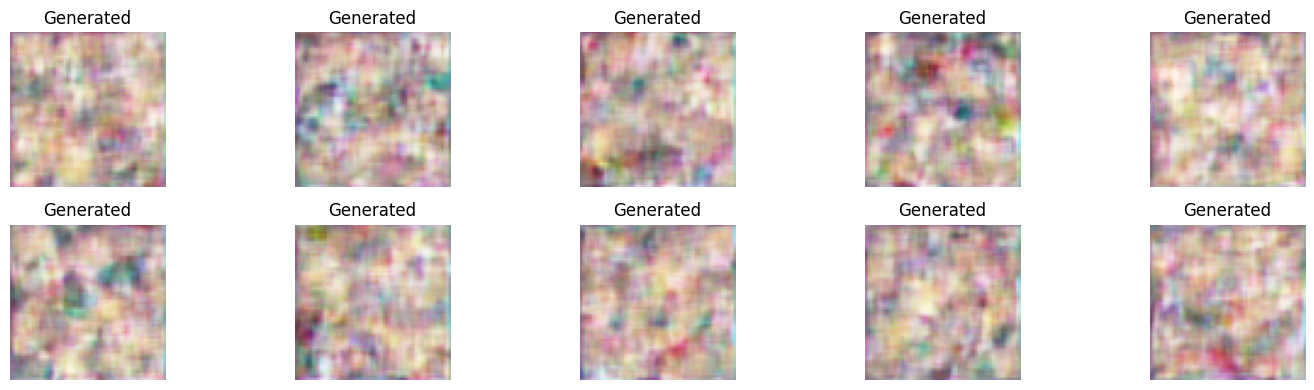

In [12]:
plt.figure(figsize=(15, 4))

for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(gen_images[i])
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

Multiple parameters were experimented on during the creation of this notebook, which included different architectures than the one being showcased. Sadly, the results were not satisfactory and the output is similar to a _deep dream_, in which the **model learnt the patterns of the images (thanks to the perceptual loss function) but wasn't able to correctly reconstruct them**s. 

The outputs above are evidence of the Neural Network's pattern identification and learning. After all, Perceptual Generative Autoencoders were formulated after Generative Adversarial Network's (GAN) principles and architectures, or hand in hand with Variational AEs (also known as Perceptual Variational Autoencoders).  